In [1]:
import pandas as pd #To hand with data 
import numpy as np #To math 
import seaborn as sns #to visualization
import matplotlib.pyplot as plt # to plot the graphs
import matplotlib.gridspec as gridspec # to do the grid of plots

In [2]:
#loading the data
try:
    train = pd.read_csv("../data/fraudTrain.csv")
    test = pd.read_csv("../data/fraudTest.csv")
    print("Successfully loaded training and test datasets")
    print(f"Training set shape: {train.shape}")
    print(f"Test set shape: {test.shape}")
except FileNotFoundError:
    print("Error: Please ensure you have downloaded both 'fraudTrain.csv' and 'fraudTest.csv' from:")
    print("https://www.kaggle.com/kartik2112/fraud-detection")
    print("And placed them in the 'data' directory")

Successfully loaded training and test datasets
Training set shape: (1296675, 23)
Test set shape: (555719, 23)


In [3]:
train['trans_date_trans_time']=pd.to_datetime(train['trans_date_trans_time'])
train['trans_date']=train['trans_date_trans_time'].dt.strftime('%Y-%m-%d')
train['trans_date']=pd.to_datetime(train['trans_date'])
train['dob']=pd.to_datetime(train['dob'])

test['trans_date_trans_time']=pd.to_datetime(test['trans_date_trans_time'])
test['trans_date']=test['trans_date_trans_time'].dt.strftime('%Y-%m-%d')
test['trans_date']=pd.to_datetime(test['trans_date'])
test['dob']=pd.to_datetime(test['dob'])
test.trans_date.head(),test.dob.head(),train.trans_date.head(),train.dob.head()

train.drop("Unnamed: 0",axis=1,inplace=True)
test.drop("Unnamed: 0",axis=1,inplace=True)

In [4]:
total = pd.concat([test,train])
total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   trans_date_trans_time  datetime64[ns]
 1   cc_num                 int64         
 2   merchant               object        
 3   category               object        
 4   amt                    float64       
 5   first                  object        
 6   last                   object        
 7   gender                 object        
 8   street                 object        
 9   city                   object        
 10  state                  object        
 11  zip                    int64         
 12  lat                    float64       
 13  long                   float64       
 14  city_pop               int64         
 15  job                    object        
 16  dob                    datetime64[ns]
 17  trans_num              object        
 18  unix_time              int6

In [5]:
total['trans_month'] = pd.DatetimeIndex(total['trans_date']).month
total['trans_year'] = pd.DatetimeIndex(total['trans_date']).year

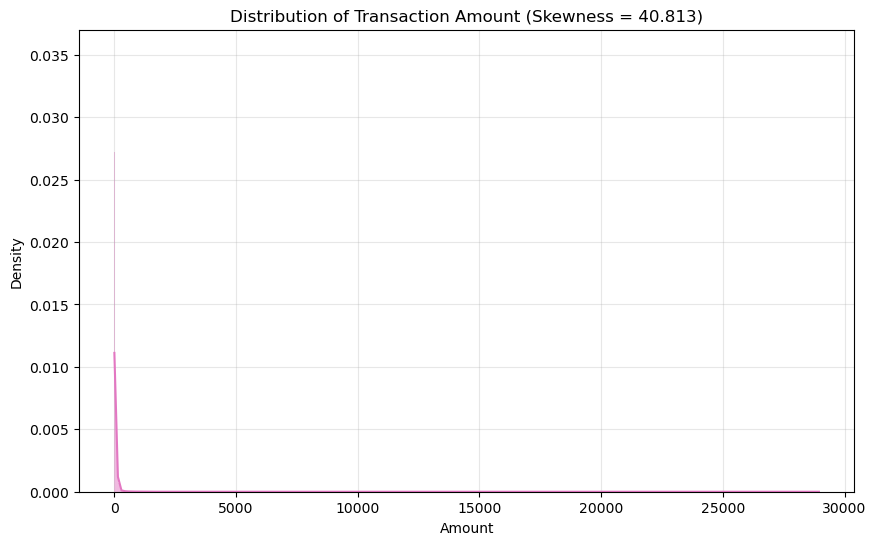

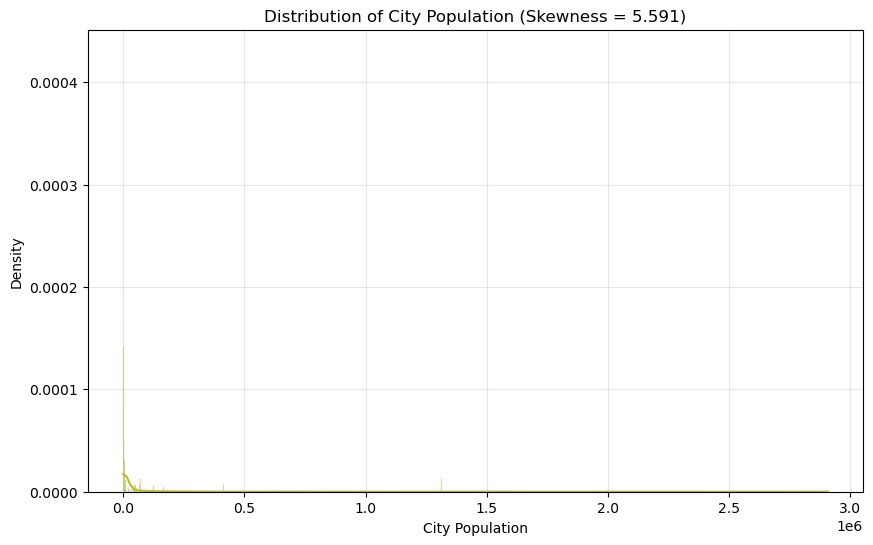

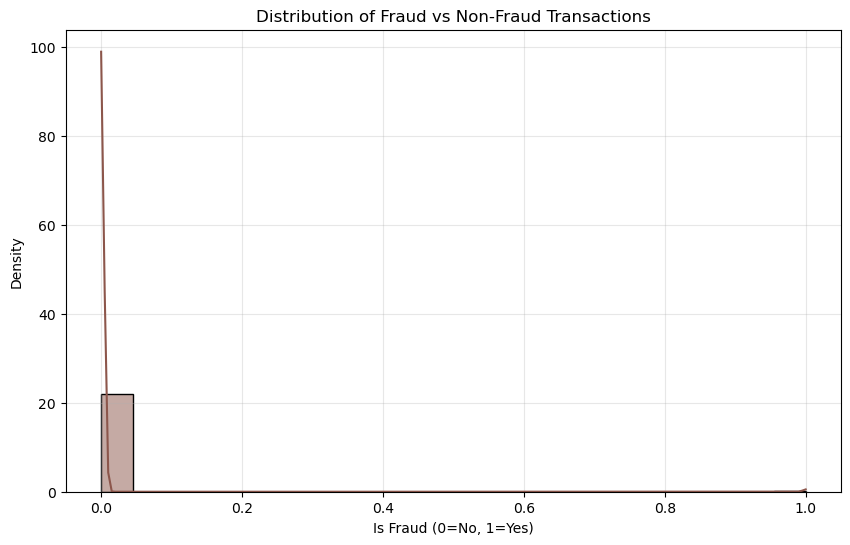

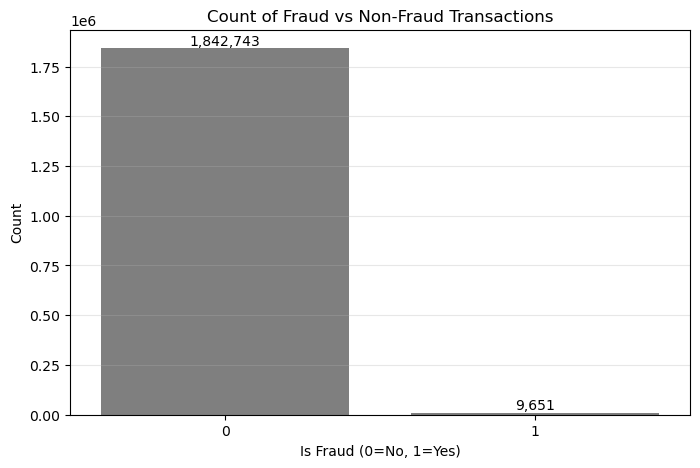


Age Statistics:
count    1.852394e+06
mean     4.576496e+01
std      1.741240e+01
min      1.300000e+01
25%      3.200000e+01
50%      4.400000e+01
75%      5.700000e+01
max      9.600000e+01
Name: age, dtype: float64


In [8]:
# Import required libraries
from scipy.stats import norm, skew
import random

# Function to generate random colors for consistency
def get_random_color():
    return random.choice(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

# Set figure parameters
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# 1. Plot Amount Distribution and Skewness
plt.figure()
skewness_amt = skew(total['amt'])
sns.histplot(data=total, x='amt', stat='density', kde=True, color=get_random_color())
plt.title(f"Distribution of Transaction Amount (Skewness = {skewness_amt:.3f})")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

# 2. Plot City Population Distribution
plt.figure()
skewness_pop = skew(total['city_pop'])
sns.histplot(data=total, x='city_pop', stat='density', kde=True, color=get_random_color())
plt.title(f"Distribution of City Population (Skewness = {skewness_pop:.3f})")
plt.xlabel("City Population")
plt.ylabel("Density")
plt.show()

# 3. Plot Fraud Distribution
plt.figure()
sns.histplot(data=total, x='is_fraud', stat='density', kde=True, color=get_random_color())
plt.title("Distribution of Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0=No, 1=Yes)")
plt.ylabel("Density")
plt.show()

# Drop unnecessary columns
columns_to_drop = ['cc_num', 'merchant', 'first', 'last', 'street', 
                   'zip', 'trans_num', 'unix_time']
total.drop(columns_to_drop, axis=1, inplace=True)

# 4. Plot Fraud Count
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="is_fraud", data=total, color=get_random_color())
plt.title("Count of Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0=No, 1=Yes)")
plt.ylabel("Count")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

# Calculate age from transaction date and date of birth
total["age"] = total["trans_date"].dt.year - total["dob"].dt.year
# Adjust age for cases where birthday hasn't occurred yet in the transaction year
total["age"] -= ((total["trans_date"].dt.month < total["dob"].dt.month) | 
                 ((total["trans_date"].dt.month == total["dob"].dt.month) & 
                  (total["trans_date"].dt.day < total["dob"].dt.day))).astype(int)

print("\nAge Statistics:")
print(total["age"].describe())